In [11]:
import sys
import os

# Move to project root (IMPORTANT)
os.chdir("..")

# Add root to Python path
sys.path.append(os.getcwd())

# Now imports will work
from src.data_loader import load_data
from src.preprocess import preprocess_data, normalize_data

# Other imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

In [12]:
# Load data
X, y = load_data()

# Preprocess
X = preprocess_data(X)
X, mean, std = normalize_data(X)

print("Data shape:", X.shape)

Data shape: (3000, 200, 14)


In [13]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# One-hot encoding
y_cat = to_categorical(y, num_classes=10)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

print("Test shape:", X_test.shape)

Test shape: (600, 200, 14)


In [14]:
model = load_model("model/airdraw_model.h5")

In [ ]:
#Predictions
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


In [16]:
#Accuracy

accuracy = np.mean(y_pred_classes == y_true)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.8133333333333334


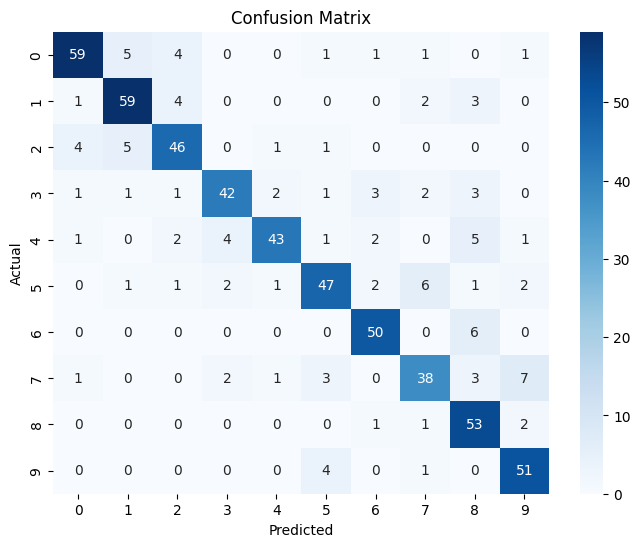

In [17]:
#Confusion matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
#Classification

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        72
           1       0.83      0.86      0.84        69
           2       0.79      0.81      0.80        57
           3       0.84      0.75      0.79        56
           4       0.90      0.73      0.80        59
           5       0.81      0.75      0.78        63
           6       0.85      0.89      0.87        56
           7       0.75      0.69      0.72        55
           8       0.72      0.93      0.81        57
           9       0.80      0.91      0.85        56

    accuracy                           0.81       600
   macro avg       0.82      0.81      0.81       600
weighted avg       0.82      0.81      0.81       600



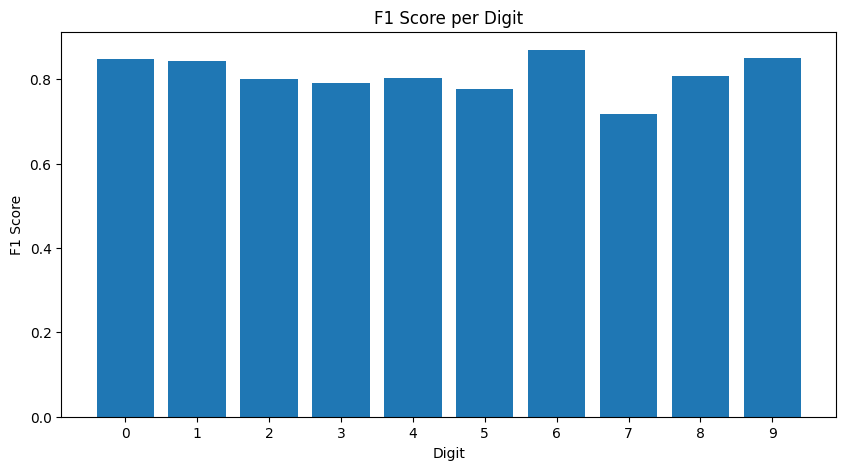

In [19]:
#F1 score per digit

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_classes)

plt.figure(figsize=(10,5))
plt.bar(range(10), f1)
plt.title("F1 Score per Digit")
plt.xlabel("Digit")
plt.ylabel("F1 Score")
plt.xticks(range(10))
plt.show()